In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("forest_cover.csv")

print(df.head())
print(df.shape)



   Unnamed: 0  Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           0     3351.0     NaN   27.0                             726.0   
1           1     2732.0   129.0    7.0                             212.0   
2           2     2572.0    24.0    9.0                             201.0   
3           3     2824.0    69.0   13.0                             417.0   
4           4     2529.0    84.0    5.0                             120.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                           124.0                           3813.0   
1                             1.0                           1082.0   
2                           689.0                            957.0   
3                            39.0                           3223.0   
4                             9.0                           1092.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  ...  Soil_Type36  \
0          192.0           252.0            NaN

In [243]:
soil_columns = [f'Soil_Type{i}' for i in range(1, 41)]
def handle_soil_types(df):
    soil_type_counts = df[soil_columns].sum()
    most_common = soil_type_counts.idxmax()
    df[soil_columns] = df[soil_columns].fillna(0)
    df[soil_columns] = df[soil_columns].astype('int64')
    def fix_row(row):# If a row does not have any Soil_Type flag of 1, it is replaced with most_common
        if 1 in row.values:
            return row
        else:
            return pd.Series([1 if col == most_common else 0 for col in soil_columns], index=soil_columns)
    df[soil_columns] = df[soil_columns].apply(fix_row, axis=1)
    return df

df = handle_soil_types(df)



In [244]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
print(missing_percentage)

columns_to_drop = [col for col in missing_percentage.index if missing_percentage[col] > 50 and col not in soil_columns]# Delete columns with more than 50% missing values (keep the soil_columns column)
df_cleaned = df.drop(columns=columns_to_drop)



Unnamed: 0                             0.000000
Elevation                             15.998056
Aspect                                22.997408
Slope                                  8.998704
Horizontal_Distance_To_Hydrology       7.997408
Vertical_Distance_To_Hydrology         5.998056
Horizontal_Distance_To_Roadways        7.997408
Hillshade_9am                         30.000000
Hillshade_Noon                        11.999352
Hillshade_3pm                         27.997408
Horizontal_Distance_To_Fire_Points    18.998704
Soil_Type1                             0.000000
Soil_Type2                             0.000000
Soil_Type3                             0.000000
Soil_Type4                             0.000000
Soil_Type5                             0.000000
Soil_Type6                             0.000000
Soil_Type7                             0.000000
Soil_Type8                             0.000000
Soil_Type9                             0.000000
Soil_Type10                            0

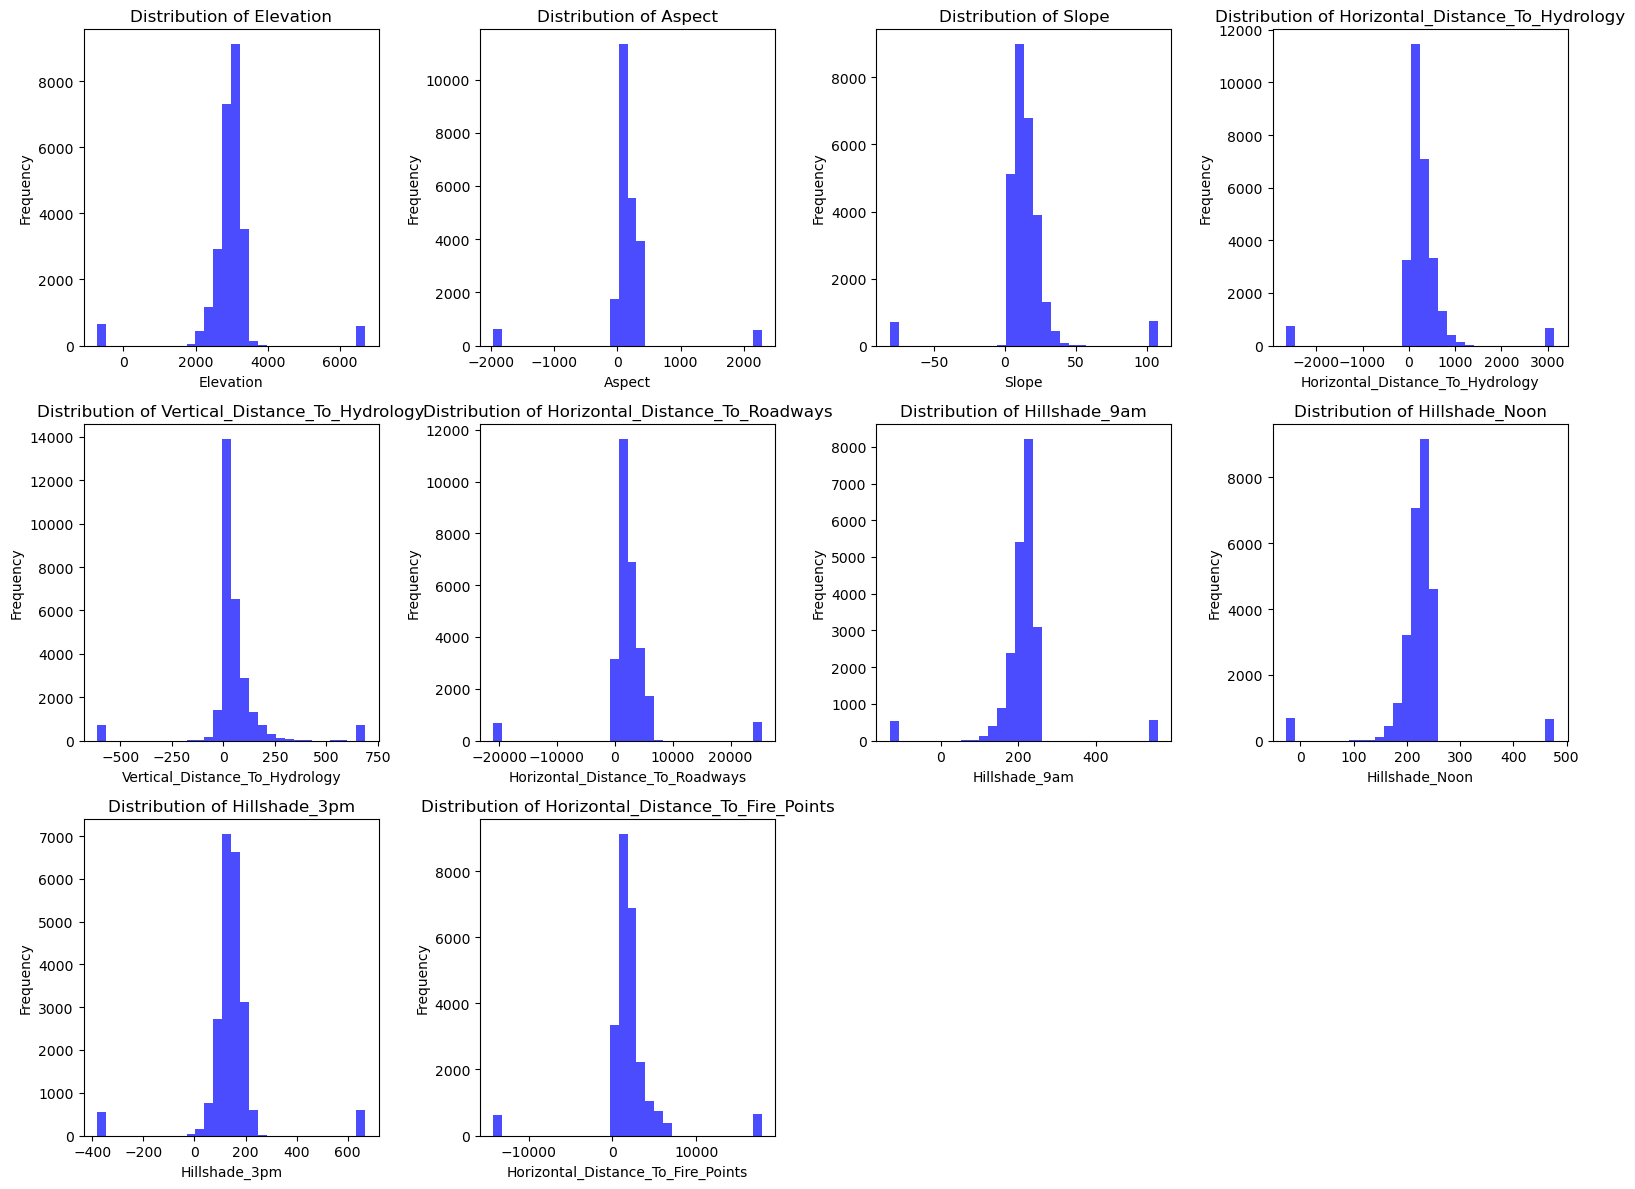

In [247]:
columns_of_interest = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology','Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

df_cleaned = df_cleaned[columns_of_interest + soil_columns + ['Forest_Cover', 'Neota', 'Rawah', 'Comanche Peak', 'Cache la Poudre']]
columns_to_plot = columns_of_interest 

plt.figure(figsize=(16, 12))# Map the distribution so I can analyze how to fill in the missing values
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 4, i) 
    df_cleaned[column].plot(kind='hist', bins=30, color='blue', alpha=0.7)
    plt.title(f'Distribution of {column}', fontsize=12)
    plt.xlabel(f'{column}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


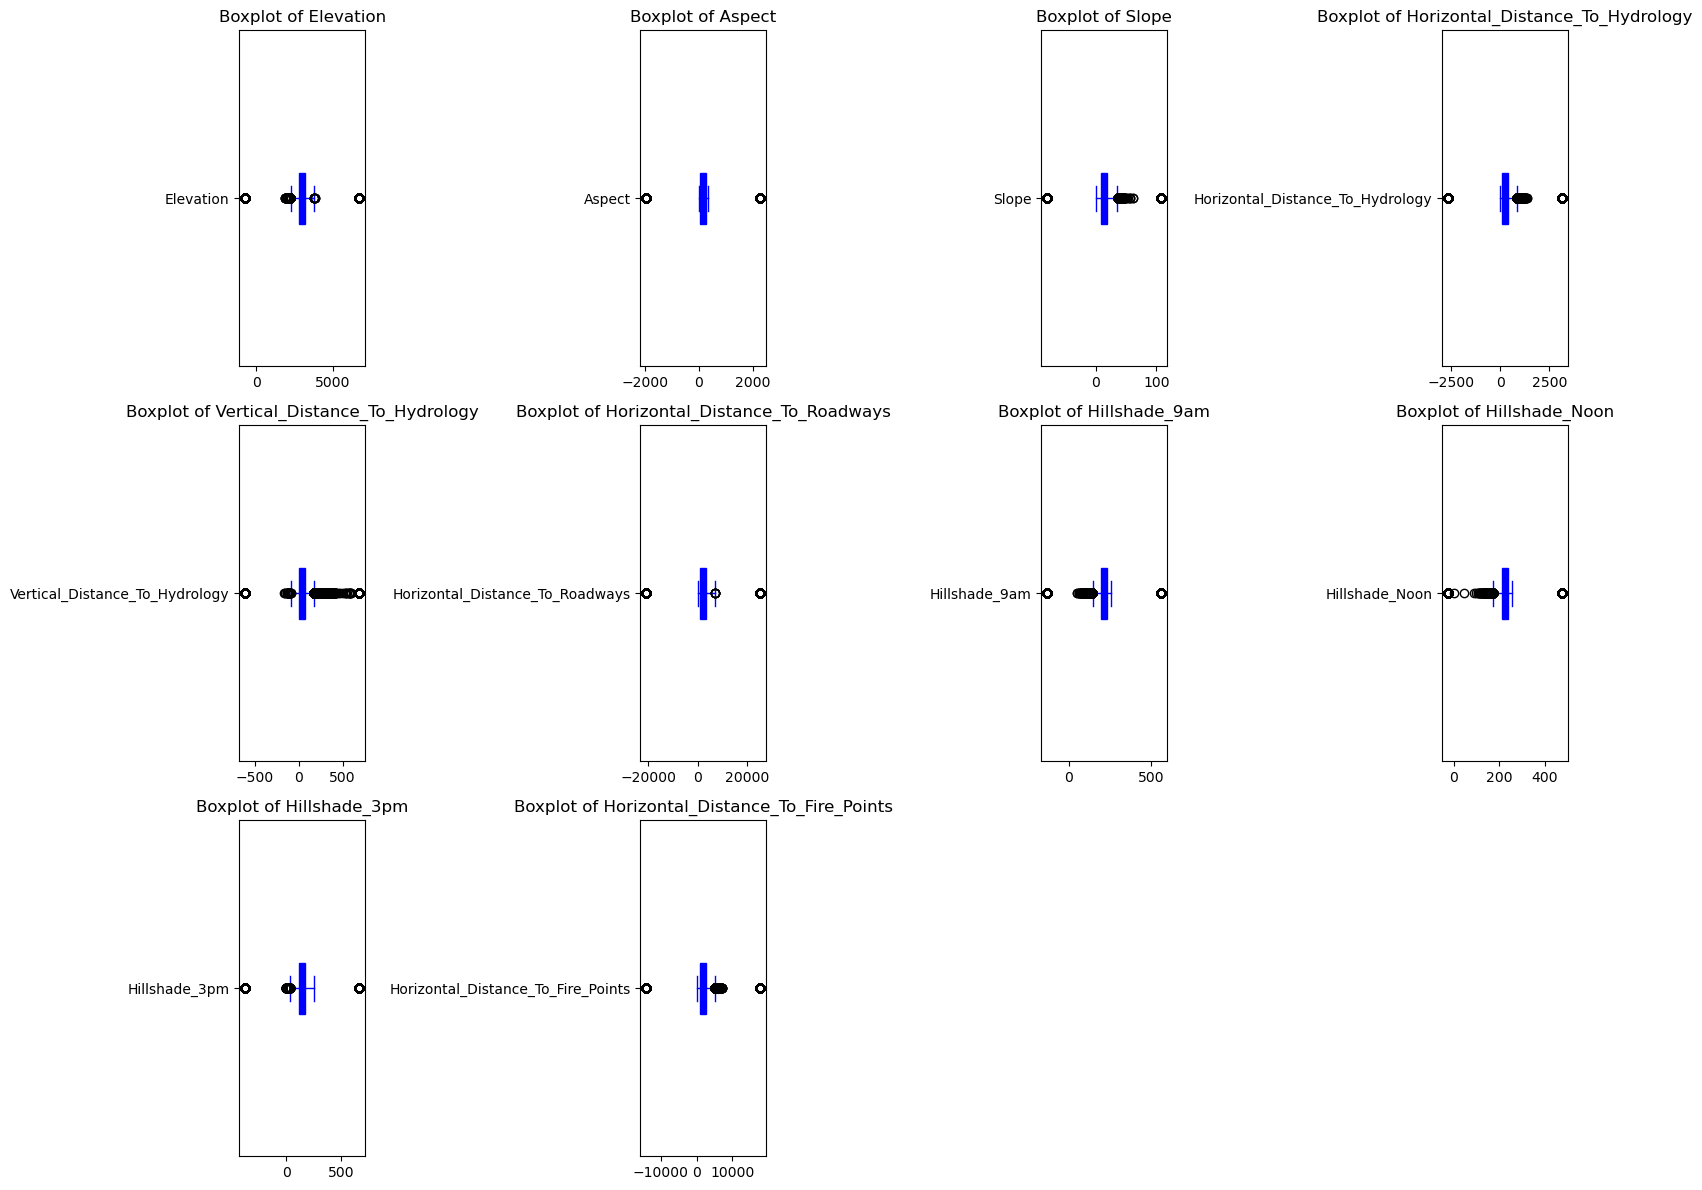

In [249]:
plt.figure(figsize=(16, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 4, i) 
    df_cleaned[column].plot(kind='box', vert=False, color='blue', patch_artist=True)
    plt.title(f'Boxplot of {column}', fontsize=12)
plt.tight_layout()
plt.show()

In [251]:
# Clear negative values in non-negative features
non_negative_cols = [
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Horizontal_Distance_To_Fire_Points'
]
for col in non_negative_cols:
    df_cleaned = df_cleaned[df_cleaned[col] >= 0]

In [253]:
# Delete outliers using IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in columns_to_plot:
    df_cleaned = remove_outliers(df_cleaned, col)

In [255]:
for col in columns_to_plot: # Fill in missing values
    if df_cleaned[col].isnull().sum() > 0:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)

Text(0, 0.5, 'Frequency')

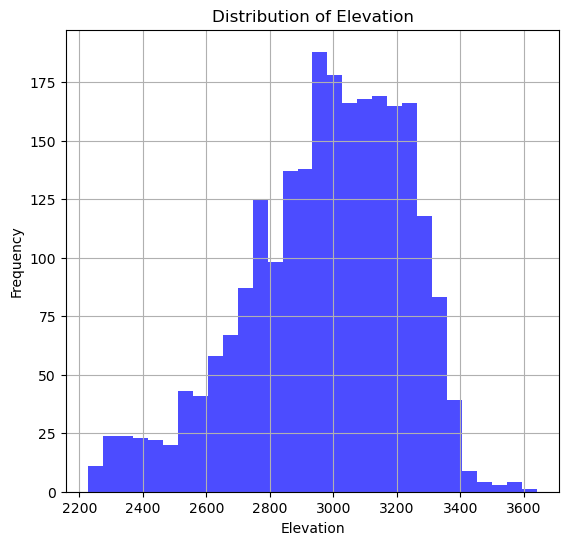

In [257]:
plt.figure(figsize=(14, 6))  # Plot the elevation histogram
plt.subplot(1, 2, 1)
df_cleaned['Elevation'].plot(kind='hist', bins=30, color='blue', alpha=0.7)
plt.grid(True)
plt.title('Distribution of Elevation')
plt.xlabel('Elevation')
plt.ylabel('Frequency')





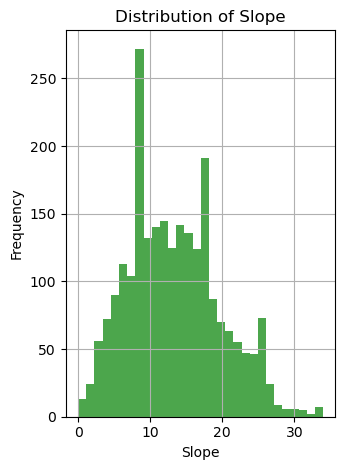

In [259]:
plt.subplot(1, 2, 2) # Plot the slope histogram
df_cleaned['Slope'].plot(kind='hist', bins=30, color='green', alpha=0.7)
plt.grid(True)
plt.title('Distribution of Slope')
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()




In [261]:
df_cleaned.to_csv("cleaned_forest_cover.csv", index=False)